In [1]:
# ============================================================
#   CORONARY ARTERY DISEASE (CAD) PREDICTION
#   Full Project for Google Colab — Educational Notebook
#   Author  : AI-generated teaching material
#   Dataset : Cleveland Heart Disease (UCI ML Repository)
#   Models  : Logistic Regression | Random Forest | XGBoost
# ============================================================

# ─────────────────────────────────────────────────────────────
# CELL 1 ▸ Install & Import Libraries
# ─────────────────────────────────────────────────────────────
# Run this cell first — installs any missing packages
!pip install xgboost shap --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, learning_curve)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report,
                              ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap

# Notebook display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

print("✅  All libraries imported successfully!")

✅  All libraries imported successfully!


In [2]:
# ─────────────────────────────────────────────────────────────
# CELL 2 ▸ Load & Understand the Dataset
# ─────────────────────────────────────────────────────────────
"""
DATASET: Cleveland Heart Disease (UCI ML Repository)
─────────────────────────────────────────────────────
303 patients · 13 clinical features · 1 target variable

FEATURES:
  age        – Age in years
  sex        – Sex (1 = male, 0 = female)
  cp         – Chest pain type (0=typical, 1=atypical, 2=non-anginal, 3=asymptomatic)
  trestbps   – Resting blood pressure (mmHg)
  chol       – Serum cholesterol (mg/dL)
  fbs        – Fasting blood sugar > 120 mg/dL (1=yes, 0=no)
  restecg    – Resting ECG results (0=normal, 1=ST-T abnormality, 2=LV hypertrophy)
  thalach    – Maximum heart rate achieved (bpm)
  exang      – Exercise-induced angina (1=yes, 0=no)
  oldpeak    – ST depression induced by exercise relative to rest
  slope      – Slope of peak exercise ST segment (0=upsloping, 1=flat, 2=downsloping)
  ca         – Number of major vessels colored by fluoroscopy (0–3)
  thal       – Thalassemia (1=normal, 2=fixed defect, 3=reversible defect)

TARGET:
  0  →  No Coronary Artery Disease
  1  →  Coronary Artery Disease present
"""

COLUMN_NAMES = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

URL = ("https://archive.ics.uci.edu/ml/machine-learning-databases/"
       "heart-disease/processed.cleveland.data")

df_raw = pd.read_csv(URL, header=None, names=COLUMN_NAMES, na_values='?')

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"\n  Rows   : {df_raw.shape[0]}")
print(f"  Columns: {df_raw.shape[1]}")
print(f"\n  Missing values per column:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print(f"\n  First 5 rows:")
df_raw.head()



  DATASET OVERVIEW

  Rows   : 303
  Columns: 14

  Missing values per column:
ca      4
thal    2
dtype: int64

  First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0000,1.0000,1.0000,145.0000,233.0000,1.0000,2.0000,150.0000,0.0000,2.3000,3.0000,0.0000,6.0000,0
1,67.0000,1.0000,4.0000,160.0000,286.0000,0.0000,2.0000,108.0000,1.0000,1.5000,2.0000,3.0000,3.0000,2
2,67.0000,1.0000,4.0000,120.0000,229.0000,0.0000,2.0000,129.0000,1.0000,2.6000,2.0000,2.0000,7.0000,1
3,37.0000,1.0000,3.0000,130.0000,250.0000,0.0000,0.0000,187.0000,0.0000,3.5000,3.0000,0.0000,3.0000,0
4,41.0000,0.0000,2.0000,130.0000,204.0000,0.0000,2.0000,172.0000,0.0000,1.4000,1.0000,0.0000,3.0000,0


In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 ▸ Data Preprocessing & Cleaning
# ─────────────────────────────────────────────────────────────

df = df_raw.copy()

# Step 1: Drop rows with missing values (only 6 rows affected)
df.dropna(inplace=True)
print(f"After dropping NaN rows: {df.shape[0]} rows remain\n")

# Step 2: Convert target to binary (0 = no CAD, 1 = CAD)
df['target'] = (df['target'] > 0).astype(int)

# Step 3: Summary statistics
print("=" * 60)
print("  STATISTICAL SUMMARY")
print("=" * 60)
print(df.describe().round(2))

# Step 4: Class distribution
print("\n" + "=" * 60)
print("  CLASS DISTRIBUTION")
print("=" * 60)
counts = df['target'].value_counts()
print(f"\n  No CAD (0) : {counts[0]} patients ({counts[0]/len(df)*100:.1f}%)")
print(f"  CAD    (1) : {counts[1]} patients ({counts[1]/len(df)*100:.1f}%)")
print("\n✅  Preprocessing complete!")

After dropping NaN rows: 297 rows remain

  STATISTICAL SUMMARY
           age      sex       cp  trestbps     chol      fbs  restecg  \
count 297.0000 297.0000 297.0000  297.0000 297.0000 297.0000 297.0000   
mean   54.5400   0.6800   3.1600  131.6900 247.3500   0.1400   1.0000   
std     9.0500   0.4700   0.9600   17.7600  52.0000   0.3500   0.9900   
min    29.0000   0.0000   1.0000   94.0000 126.0000   0.0000   0.0000   
25%    48.0000   0.0000   3.0000  120.0000 211.0000   0.0000   0.0000   
50%    56.0000   1.0000   3.0000  130.0000 243.0000   0.0000   1.0000   
75%    61.0000   1.0000   4.0000  140.0000 276.0000   0.0000   2.0000   
max    77.0000   1.0000   4.0000  200.0000 564.0000   1.0000   2.0000   

       thalach    exang  oldpeak    slope       ca     thal   target  
count 297.0000 297.0000 297.0000 297.0000 297.0000 297.0000 297.0000  
mean  149.6000   0.3300   1.0600   1.6000   0.6800   4.7300   0.4600  
std    22.9400   0.4700   1.1700   0.6200   0.9400   1.9400   0.5

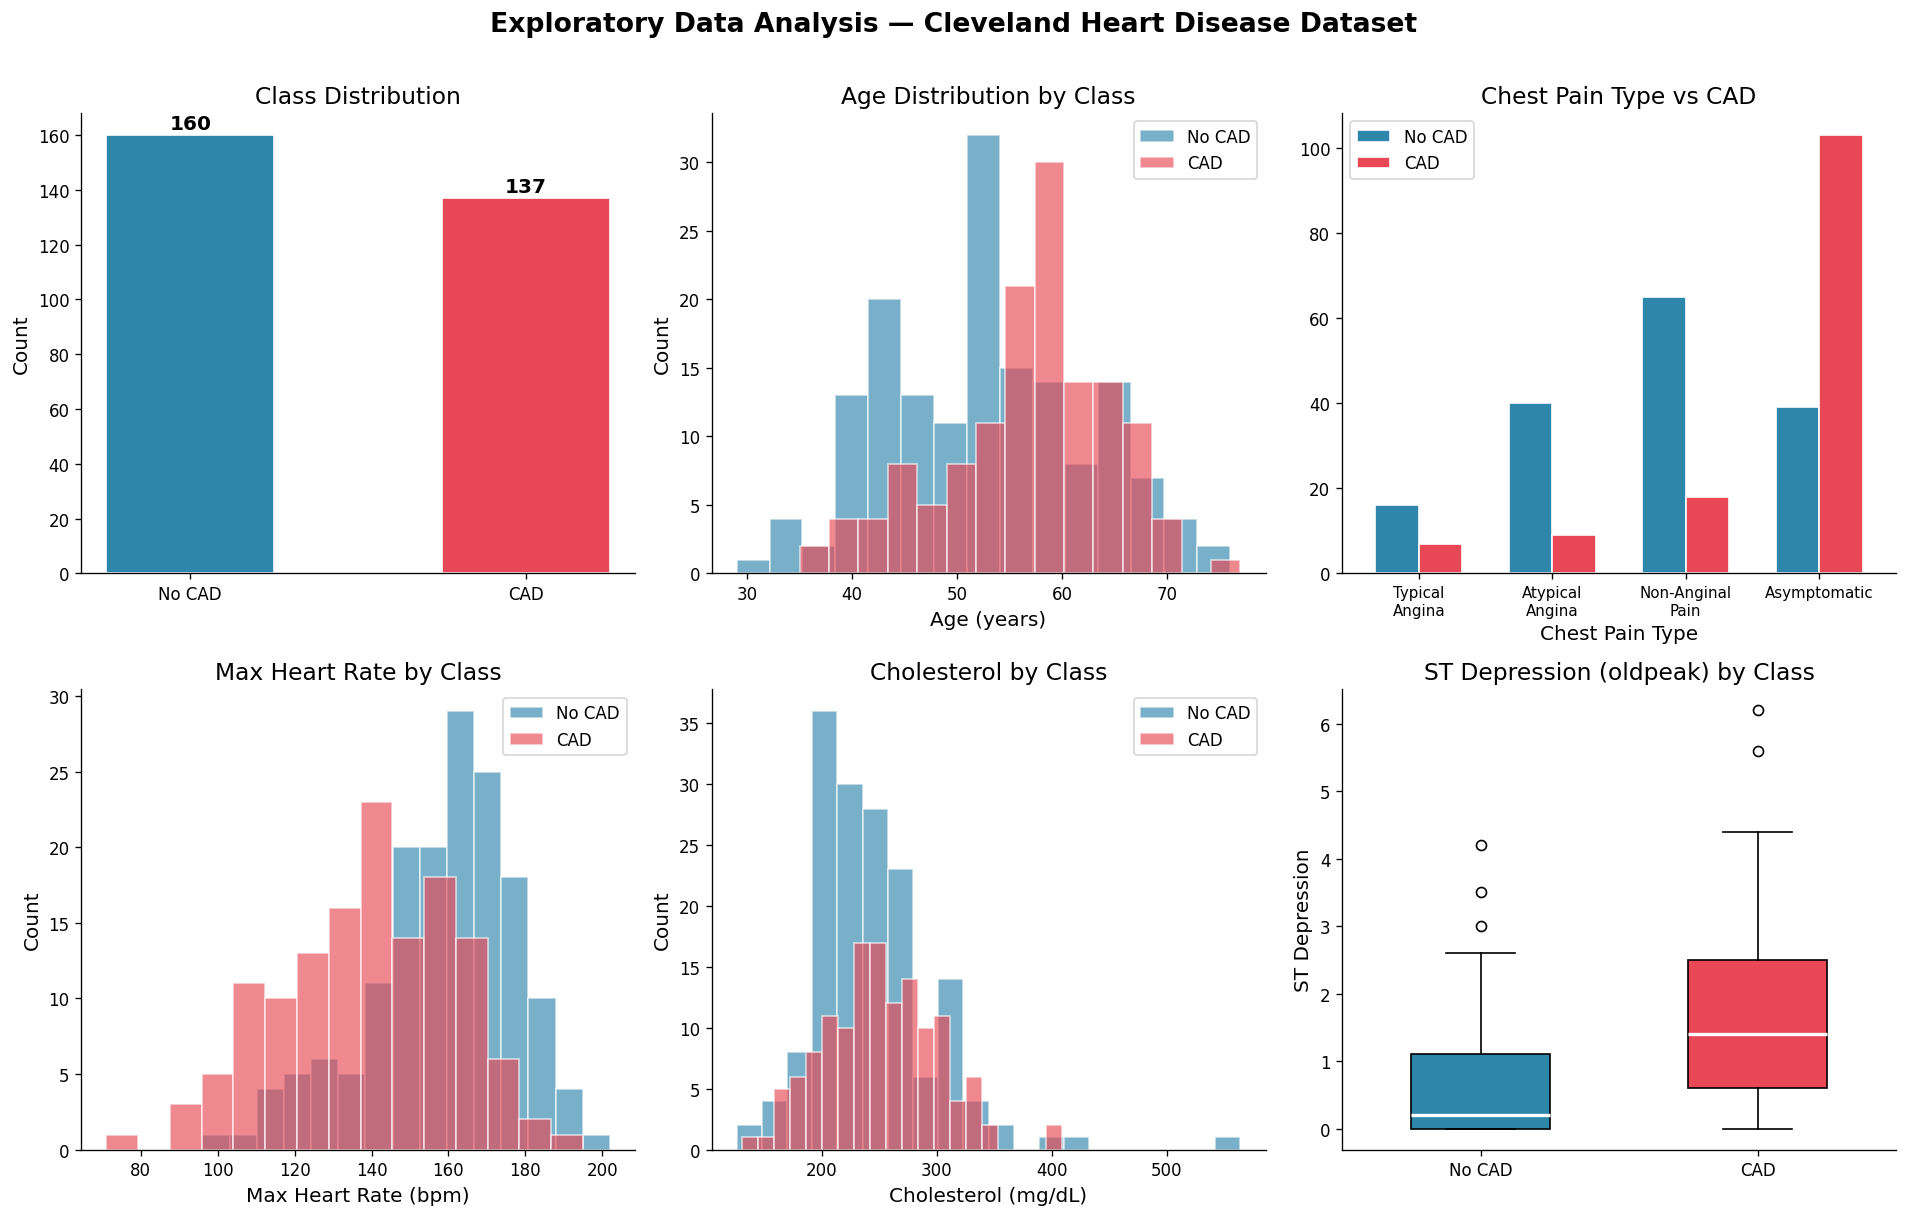

✅  EDA plots saved as 'eda_plots.png'


In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 ▸ Exploratory Data Analysis (EDA)
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploratory Data Analysis — Cleveland Heart Disease Dataset',
             fontsize=16, fontweight='bold', y=1.01)

palette = {0: '#2E86AB', 1: '#E84855'}
labels  = {0: 'No CAD', 1: 'CAD'}

# Plot 1: Class distribution
ax = axes[0, 0]
bars = ax.bar(['No CAD', 'CAD'], counts.values,
              color=['#2E86AB', '#E84855'], width=0.5, edgecolor='white')
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=12, fontweight='bold')

# Plot 2: Age distribution by class
ax = axes[0, 1]
for cls, color in palette.items():
    subset = df[df['target'] == cls]['age']
    ax.hist(subset, bins=15, alpha=0.65, color=color, label=labels[cls], edgecolor='white')
ax.set_title('Age Distribution by Class')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()

# Plot 3: Chest pain type vs target
ax = axes[0, 2]
cp_labels = ['Typical\nAngina', 'Atypical\nAngina', 'Non-Anginal\nPain', 'Asymptomatic']
cp_counts = df.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_counts.plot(kind='bar', ax=ax, color=['#2E86AB', '#E84855'],
               edgecolor='white', rot=0, width=0.65)
ax.set_title('Chest Pain Type vs CAD')
ax.set_xlabel('Chest Pain Type')
ax.set_xticklabels(cp_labels, fontsize=9)
ax.legend(['No CAD', 'CAD'])

# Plot 4: Max heart rate by class
ax = axes[1, 0]
for cls, color in palette.items():
    subset = df[df['target'] == cls]['thalach']
    ax.hist(subset, bins=15, alpha=0.65, color=color, label=labels[cls], edgecolor='white')
ax.set_title('Max Heart Rate by Class')
ax.set_xlabel('Max Heart Rate (bpm)')
ax.set_ylabel('Count')
ax.legend()

# Plot 5: Cholesterol distribution
ax = axes[1, 1]
for cls, color in palette.items():
    subset = df[df['target'] == cls]['chol']
    ax.hist(subset, bins=20, alpha=0.65, color=color, label=labels[cls], edgecolor='white')
ax.set_title('Cholesterol by Class')
ax.set_xlabel('Cholesterol (mg/dL)')
ax.set_ylabel('Count')
ax.legend()

# Plot 6: ST depression (oldpeak) boxplot
ax = axes[1, 2]
data_to_plot = [df[df['target'] == 0]['oldpeak'].values,
                df[df['target'] == 1]['oldpeak'].values]
bp = ax.boxplot(data_to_plot, patch_artist=True, widths=0.5,
                medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][1].set_facecolor('#E84855')
ax.set_title('ST Depression (oldpeak) by Class')
ax.set_xticklabels(['No CAD', 'CAD'])
ax.set_ylabel('ST Depression')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  EDA plots saved as 'eda_plots.png'")


# ─────────────────────────────────────────────────────────────

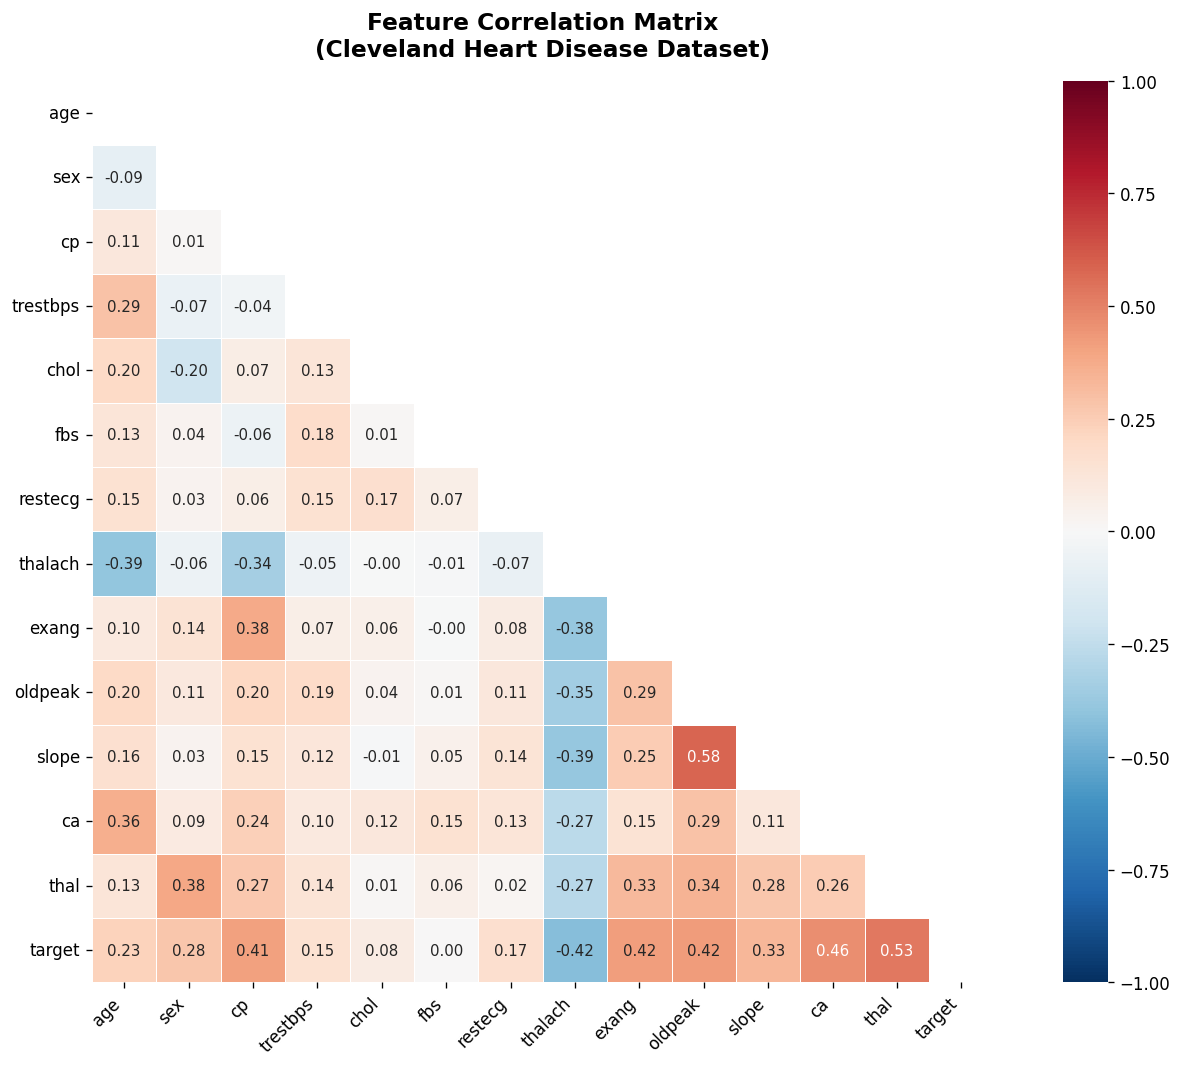

✅  Correlation heatmap saved as 'correlation_heatmap.png'


In [5]:
# CELL 5 ▸ Correlation Heatmap
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size': 9}, vmin=-1, vmax=1)

plt.title('Feature Correlation Matrix\n(Cleveland Heart Disease Dataset)',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Correlation heatmap saved as 'correlation_heatmap.png'")


In [6]:
# ─────────────────────────────────────────────────────────────
# CELL 6 ▸ Feature Engineering & Train/Test Split
# ─────────────────────────────────────────────────────────────

X = df.drop('target', axis=1)
y = df['target']

FEATURE_NAMES = X.columns.tolist()

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("=" * 60)
print("  TRAIN / TEST SPLIT")
print("=" * 60)
print(f"\n  Training set : {X_train.shape[0]} samples")
print(f"  Test set     : {X_test.shape[0]} samples")
print(f"\n  Train class balance : {dict(y_train.value_counts())}")
print(f"  Test  class balance : {dict(y_test.value_counts())}")
print("\n✅  Data split complete!")


  TRAIN / TEST SPLIT

  Training set : 237 samples
  Test set     : 60 samples

  Train class balance : {0: np.int64(128), 1: np.int64(109)}
  Test  class balance : {0: np.int64(32), 1: np.int64(28)}

✅  Data split complete!


In [7]:
# ─────────────────────────────────────────────────────────────
# CELL 7 ▸ Build Three ML Models
# ─────────────────────────────────────────────────────────────

# --- Model 1: Logistic Regression ---
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        class_weight='balanced',
        max_iter=1000,
        solver='lbfgs',
        random_state=42
    ))
])

# --- Model 2: Random Forest ---
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        max_depth=6,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# --- Model 3: XGBoost ---
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    ))
])

# --- Ensemble: Soft Voting Classifier ---
ensemble = VotingClassifier(
    estimators=[
        ('lr',  lr_pipeline),
        ('rf',  rf_pipeline),
        ('xgb', xgb_pipeline)
    ],
    voting='soft'
)

models = {
    'Logistic Regression': lr_pipeline,
    'Random Forest':       rf_pipeline,
    'XGBoost':             xgb_pipeline,
    'Voting Ensemble':     ensemble,
}

print("✅  All three models + ensemble defined!")
print("\n  Models:")
for name in models:
    print(f"    • {name}")

✅  All three models + ensemble defined!

  Models:
    • Logistic Regression
    • Random Forest
    • XGBoost
    • Voting Ensemble


In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 8 ▸ 5-Fold Cross-Validation Comparison
# ─────────────────────────────────────────────────────────────

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print("=" * 65)
print(f"  {'Model':<25} {'AUC Mean':>10} {'AUC Std':>10} {'Acc Mean':>10}")
print("=" * 65)

for name, model in models.items():
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = {'auc': auc_scores, 'acc': acc_scores}
    print(f"  {name:<25} {auc_scores.mean():>10.4f} {auc_scores.std():>10.4f} {acc_scores.mean():>10.4f}")

print("=" * 65)
print("\n✅  Cross-validation complete!")

  Model                       AUC Mean    AUC Std   Acc Mean
  Logistic Regression           0.8930     0.0396     0.8247
  Random Forest                 0.8969     0.0421     0.8047
  XGBoost                       0.8766     0.0492     0.8181
  Voting Ensemble               0.8943     0.0430     0.8146

✅  Cross-validation complete!


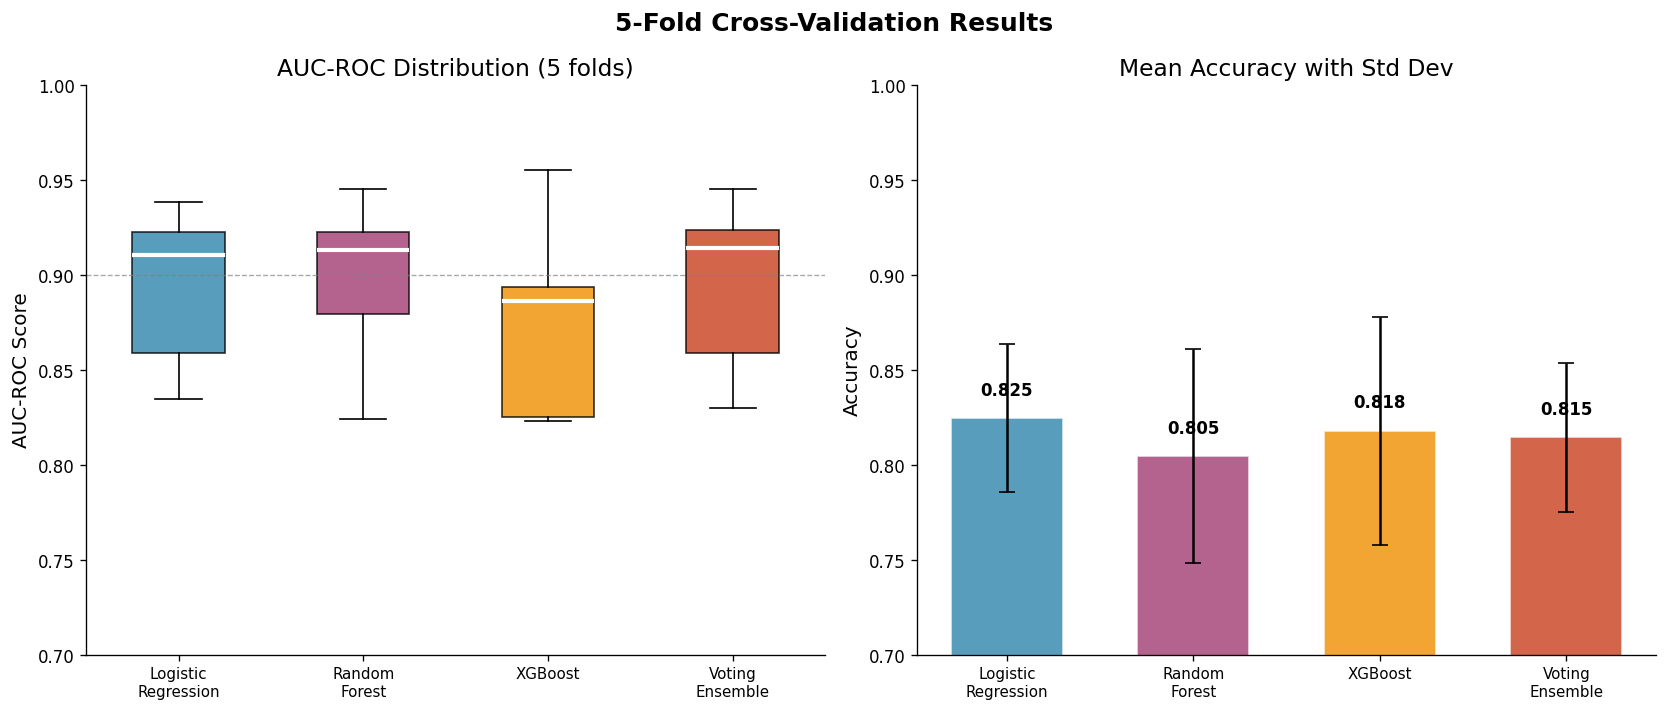

✅  CV results saved as 'cv_results.png'


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 9 ▸ Visualise Cross-Validation Results
# ─────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=15, fontweight='bold')

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
names  = list(cv_results.keys())

# AUC boxplot
auc_data = [cv_results[n]['auc'] for n in names]
bp1 = ax1.boxplot(auc_data, patch_artist=True, widths=0.5,
                  medianprops=dict(color='white', linewidth=2.5))
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax1.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax1.set_ylabel('AUC-ROC Score')
ax1.set_title('AUC-ROC Distribution (5 folds)')
ax1.set_ylim(0.7, 1.0)
ax1.axhline(0.9, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

# Accuracy bar chart with error bars
means = [cv_results[n]['acc'].mean() for n in names]
stds  = [cv_results[n]['acc'].std()  for n in names]
bars  = ax2.bar(range(len(names)), means, color=colors, alpha=0.8,
                yerr=stds, capsize=5, edgecolor='white', width=0.6)
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels([n.replace(' ', '\n') for n in names], fontsize=9)
ax2.set_ylabel('Accuracy')
ax2.set_title('Mean Accuracy with Std Dev')
ax2.set_ylim(0.7, 1.0)
for bar, mean in zip(bars, means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
             f'{mean:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  CV results saved as 'cv_results.png'")

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 10 ▸ Train Best Model & Evaluate on Test Set
# ─────────────────────────────────────────────────────────────

# Train XGBoost (best single model) on full training set
best_model = xgb_pipeline
best_model.fit(X_train, y_train)

y_pred      = best_model.predict(X_test)
y_prob      = best_model.predict_proba(X_test)[:, 1]

acc   = accuracy_score(y_test, y_pred)
prec  = precision_score(y_test, y_pred)
rec   = recall_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred)
auc   = roc_auc_score(y_test, y_prob)

print("=" * 60)
print("  XGBoost — TEST SET PERFORMANCE")
print("=" * 60)
print(f"\n  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1 Score  : {f1:.4f}")
print(f"  AUC-ROC   : {auc:.4f}")
print("\n  Full Classification Report:")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['No CAD', 'CAD']))


  XGBoost — TEST SET PERFORMANCE

  Accuracy  : 0.8667  (86.7%)
  Precision : 0.8846
  Recall    : 0.8214
  F1 Score  : 0.8519
  AUC-ROC   : 0.9252

  Full Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

      No CAD       0.85      0.91      0.88        32
         CAD       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



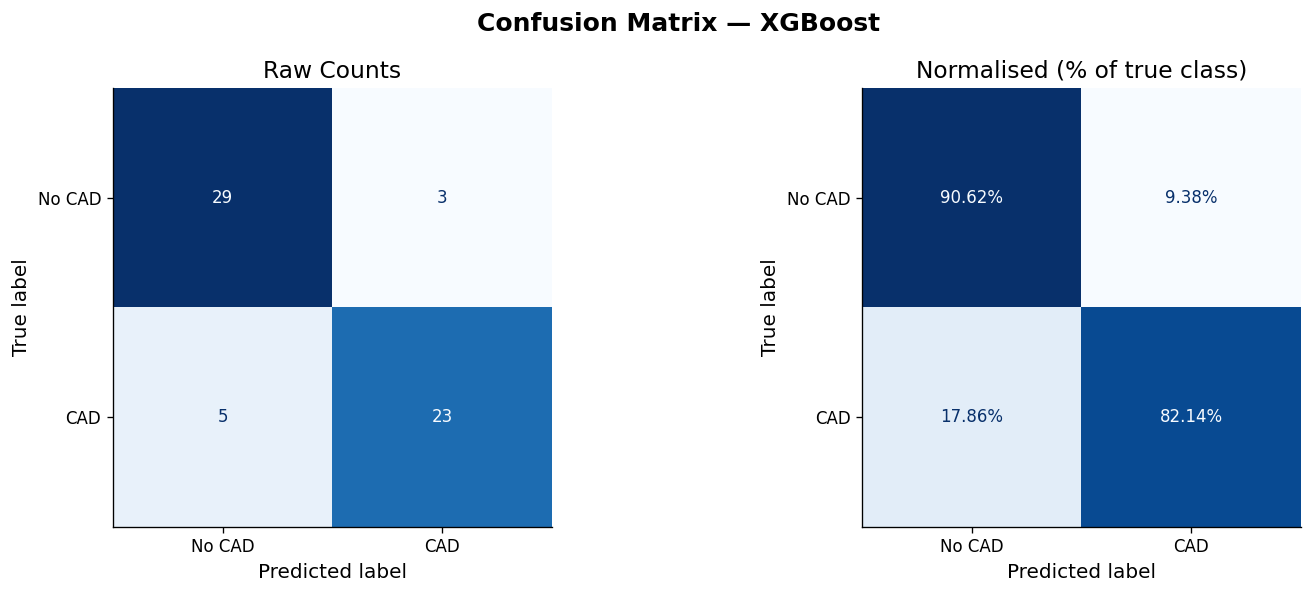

✅  Confusion matrix saved as 'confusion_matrix.png'


In [11]:
# ─────────────────────────────────────────────────────────────
# CELL 11 ▸ Confusion Matrix
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Confusion Matrix — XGBoost', fontsize=15, fontweight='bold')

cm = confusion_matrix(y_test, y_pred)

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=['No CAD', 'CAD']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Raw Counts')

# Normalised
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
ConfusionMatrixDisplay(cm_norm, display_labels=['No CAD', 'CAD']).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Normalised (% of true class)')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Confusion matrix saved as 'confusion_matrix.png'")

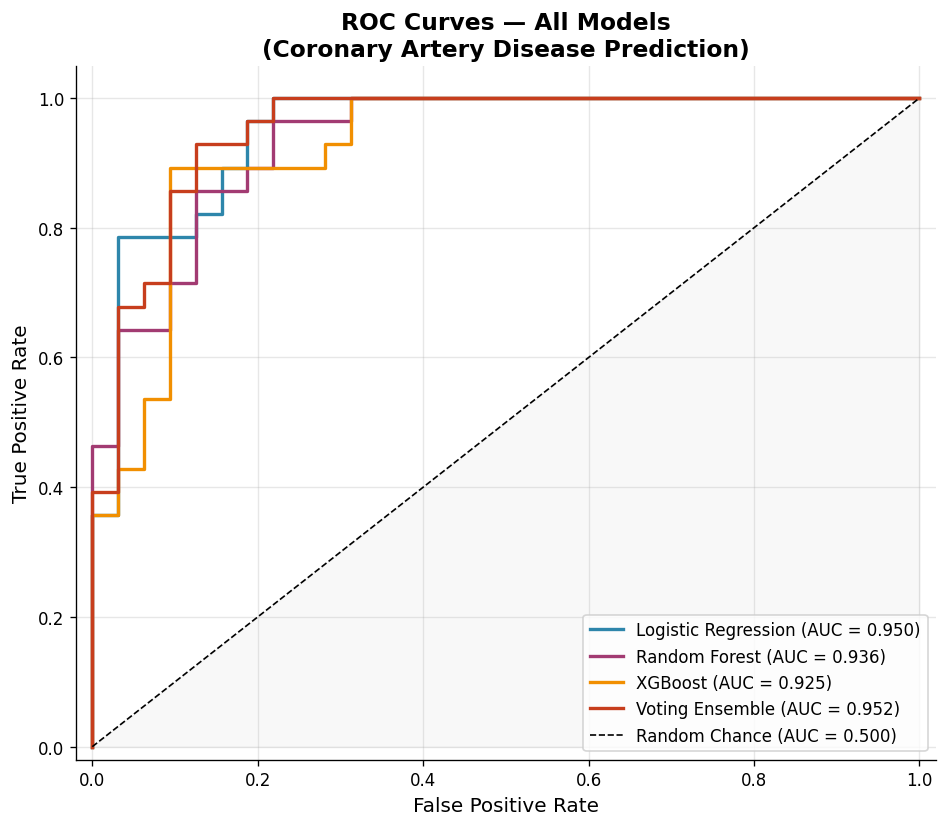

✅  ROC curves saved as 'roc_curves.png'


In [12]:
# CELL 12 ▸ ROC Curves for All Models
# ─────────────────────────────────────────────────────────────

plt.figure(figsize=(8, 7))

# Train & plot all models
roc_colors = {'Logistic Regression': '#2E86AB',
               'Random Forest':       '#A23B72',
               'XGBoost':             '#F18F01',
               'Voting Ensemble':     '#C73E1D'}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_p = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_p)
    roc_auc = roc_auc_score(y_test, y_p)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})',
             color=roc_colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Chance (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models\n(Coronary Artery Disease Prediction)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  ROC curves saved as 'roc_curves.png'")



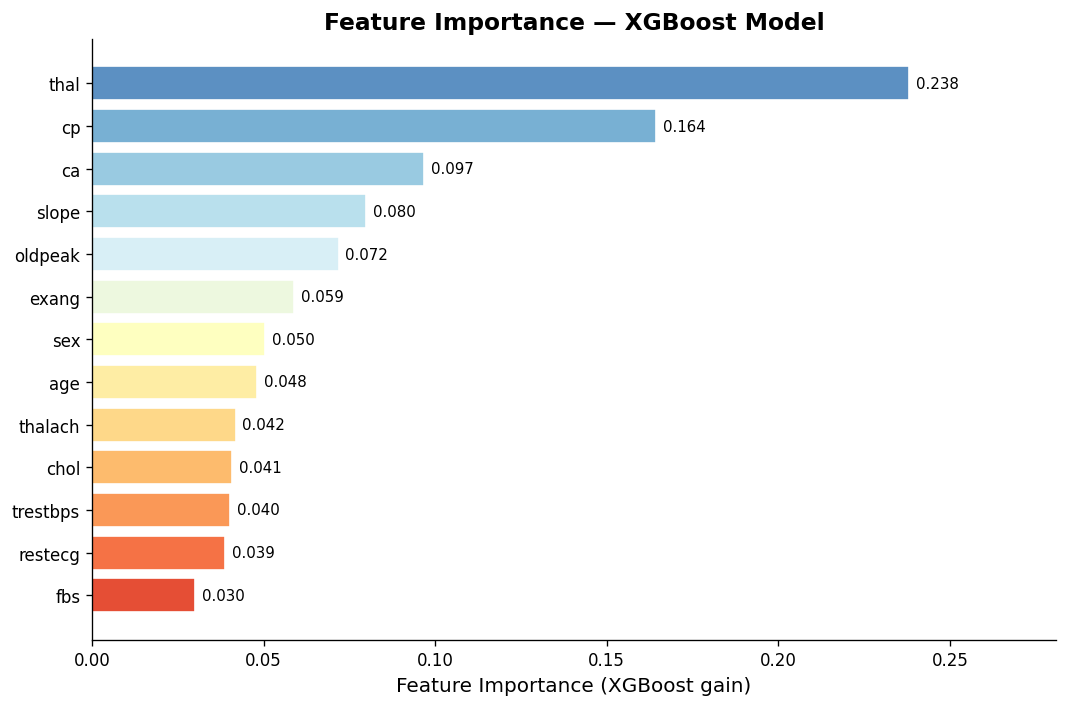

✅  Feature importance plot saved as 'feature_importance.png'


In [13]:
# ─────────────────────────────────────────────────────────────
# CELL 13 ▸ Feature Importance (XGBoost built-in)
# ─────────────────────────────────────────────────────────────

xgb_clf = xgb_pipeline.named_steps['clf']
importances = xgb_clf.feature_importances_
feat_imp_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
colors_bar = plt.cm.RdYlBu(np.linspace(0.15, 0.85, len(FEATURE_NAMES)))
bars = plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
                color=colors_bar, edgecolor='white')
for bar, val in zip(bars, feat_imp_df['Importance']):
    plt.text(val + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.xlabel('Feature Importance (XGBoost gain)', fontsize=12)
plt.title('Feature Importance — XGBoost Model', fontsize=14, fontweight='bold')
plt.xlim(0, feat_imp_df['Importance'].max() * 1.18)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Feature importance plot saved as 'feature_importance.png'")


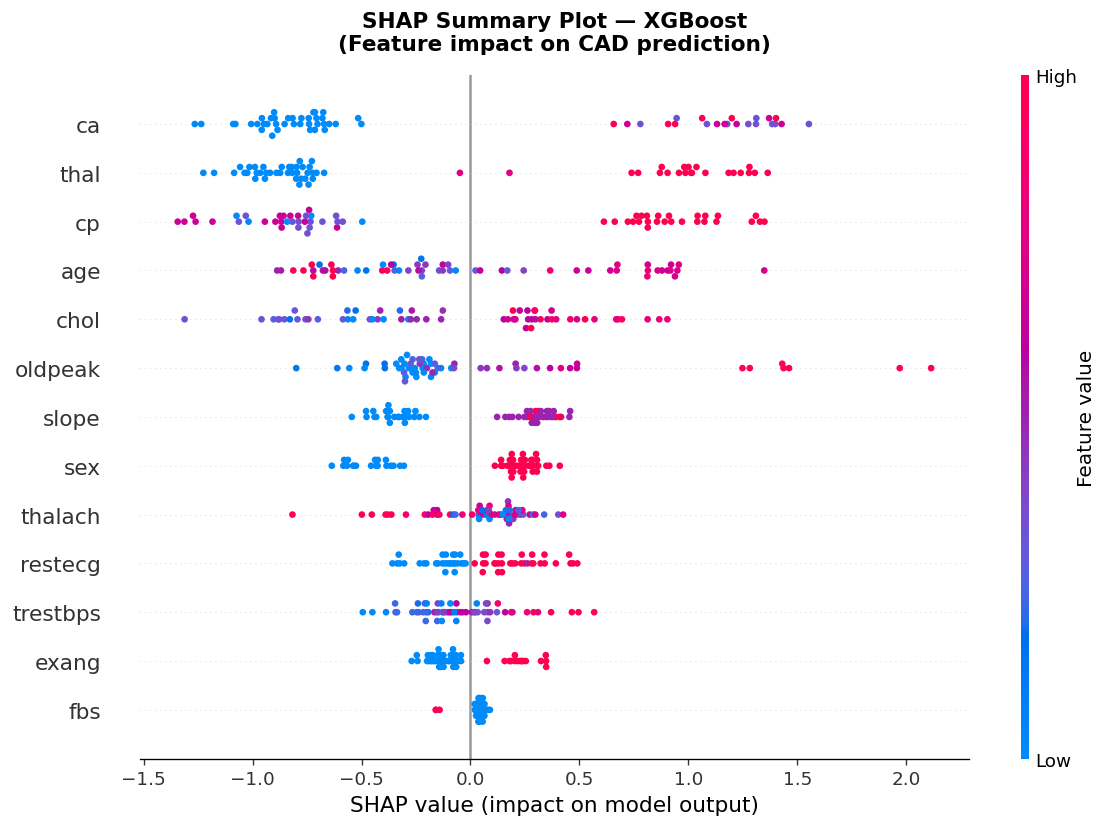

✅  SHAP summary plot saved as 'shap_summary.png'


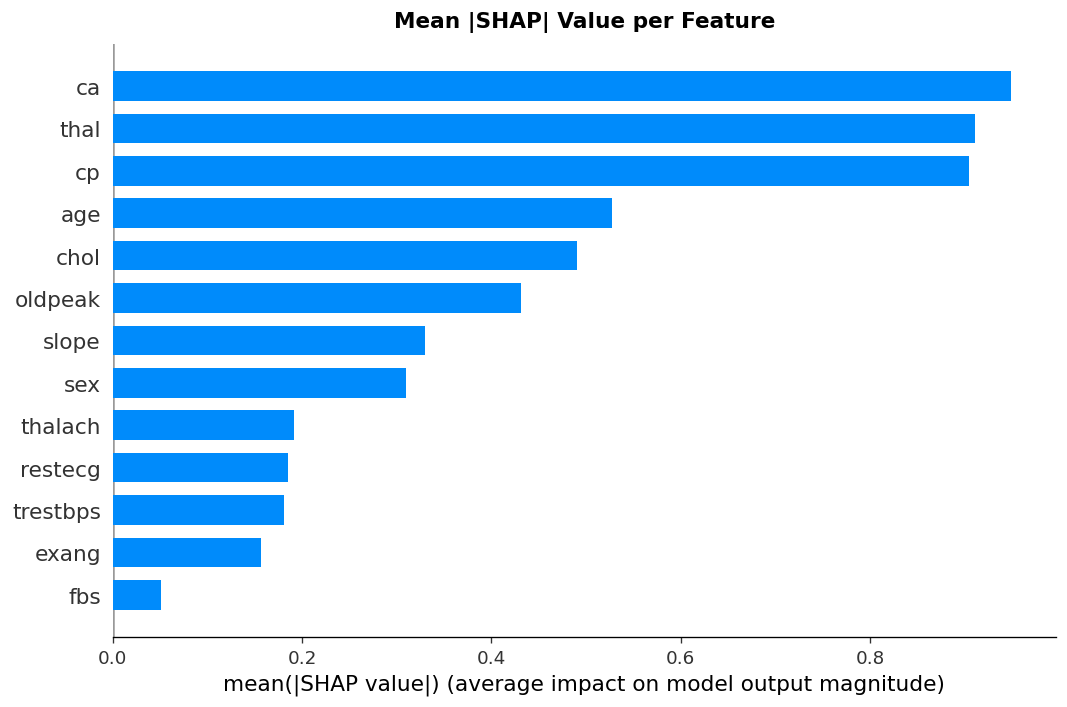

✅  SHAP bar plot saved as 'shap_bar.png'


In [14]:
# ─────────────────────────────────────────────────────────────
# CELL 14 ▸ SHAP Explainability
# ─────────────────────────────────────────────────────────────
"""
SHAP (SHapley Additive exPlanations) shows how much each
feature pushed the prediction higher or lower for each patient.
Red = pushed prediction toward CAD
Blue = pushed prediction away from CAD
"""

# Prepare scaled test data for SHAP
scaler     = xgb_pipeline.named_steps['scaler']
X_test_sc  = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_NAMES)

explainer   = shap.TreeExplainer(xgb_clf)
shap_values = explainer.shap_values(X_test_sc)

# SHAP Summary (beeswarm) plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_sc, feature_names=FEATURE_NAMES,
                  show=False, plot_size=(10, 7))
plt.title('SHAP Summary Plot — XGBoost\n(Feature impact on CAD prediction)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  SHAP summary plot saved as 'shap_summary.png'")

# SHAP Bar summary
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_sc, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, plot_size=(9, 6))
plt.title('Mean |SHAP| Value per Feature', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  SHAP bar plot saved as 'shap_bar.png'")



In [15]:
# ─────────────────────────────────────────────────────────────
# CELL 15 ▸ SHAP Force Plot — Single Patient Explanation
# ─────────────────────────────────────────────────────────────
"""
Force plot shows exactly how each feature pushed the prediction
for ONE specific patient.
"""

# Pick the first test patient as example
idx = 0
patient_features = X_test_sc.iloc[[idx]]
expected_value   = explainer.expected_value

print(f"  Patient index  : {X_test.index[idx]}")
print(f"  True label     : {'CAD' if y_test.iloc[idx] == 1 else 'No CAD'}")
pred_prob = best_model.predict_proba(X_test.iloc[[idx]])[0, 1]
print(f"  Predicted prob : {pred_prob:.4f}  →  {'CAD' if pred_prob >= 0.5 else 'No CAD'}")
print(f"\n  Patient feature values:")
print(X_test.iloc[[idx]].T.rename(columns={X_test.index[idx]: 'Value'}).to_string())

# Interactive force plot (renders in Colab)
shap.initjs()
force_plot = shap.force_plot(
    expected_value,
    shap_values[idx],
    patient_features,
    feature_names=FEATURE_NAMES
)
shap.save_html('shap_force_plot.html', force_plot)
print("\n✅  Force plot saved as 'shap_force_plot.html'")
force_plot

  Patient index  : 295
  True label     : No CAD
  Predicted prob : 0.0132  →  No CAD

  Patient feature values:
            Value
age       41.0000
sex        1.0000
cp         2.0000
trestbps 120.0000
chol     157.0000
fbs        0.0000
restecg    0.0000
thalach  182.0000
exang      0.0000
oldpeak    0.0000
slope      1.0000
ca         0.0000
thal       3.0000



✅  Force plot saved as 'shap_force_plot.html'


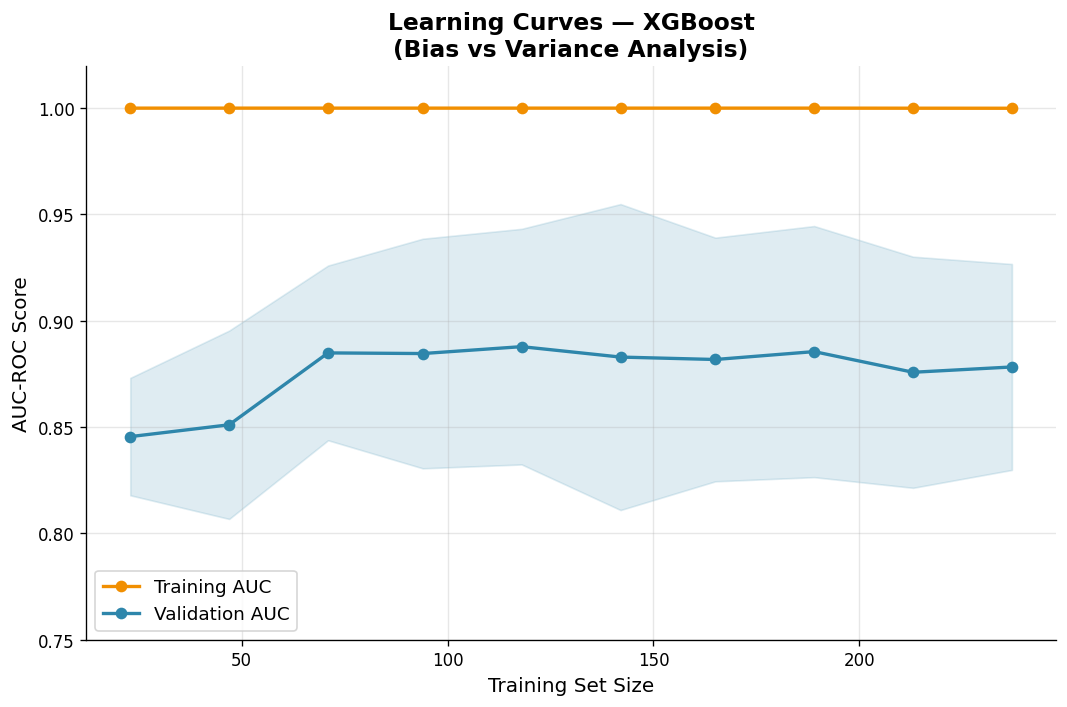

✅  Learning curves saved as 'learning_curves.png'


In [16]:
# ─────────────────────────────────────────────────────────────
# CELL 16 ▸ Learning Curves (Bias vs Variance)
# ─────────────────────────────────────────────────────────────

train_sizes, train_scores, val_scores = learning_curve(
    xgb_pipeline, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, 'o-', color='#F18F01',
         linewidth=2, markersize=6, label='Training AUC')
plt.fill_between(train_sizes, train_mean - train_std,
                 train_mean + train_std, alpha=0.15, color='#F18F01')
plt.plot(train_sizes, val_mean, 'o-', color='#2E86AB',
         linewidth=2, markersize=6, label='Validation AUC')
plt.fill_between(train_sizes, val_mean - val_std,
                 val_mean + val_std, alpha=0.15, color='#2E86AB')
plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('AUC-ROC Score', fontsize=12)
plt.title('Learning Curves — XGBoost\n(Bias vs Variance Analysis)',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.ylim(0.75, 1.02)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅  Learning curves saved as 'learning_curves.png'")


In [17]:
# ─────────────────────────────────────────────────────────────
# CELL 17 ▸ Final Performance Summary Table
# ─────────────────────────────────────────────────────────────

print("\n" + "=" * 72)
print("  FINAL MODEL PERFORMANCE SUMMARY (Test Set)")
print("=" * 72)
print(f"  {'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>7} {'AUC-ROC':>9}")
print("-" * 72)

summary_rows = []
for name, model in models.items():
    yp  = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:, 1]
    row = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall':    recall_score(y_test, yp),
        'F1':        f1_score(y_test, yp),
        'AUC-ROC':   roc_auc_score(y_test, ypr),
    }
    summary_rows.append(row)
    print(f"  {name:<22} {row['Accuracy']:>9.4f} {row['Precision']:>10.4f} "
          f"{row['Recall']:>8.4f} {row['F1']:>7.4f} {row['AUC-ROC']:>9.4f}")

print("=" * 72)
summary_df = pd.DataFrame(summary_rows).set_index('Model')
print("\n  Best model by AUC-ROC:",
      summary_df['AUC-ROC'].idxmax(),
      f"({summary_df['AUC-ROC'].max():.4f})")




  FINAL MODEL PERFORMANCE SUMMARY (Test Set)
  Model                   Accuracy  Precision   Recall      F1   AUC-ROC
------------------------------------------------------------------------
  Logistic Regression       0.8333     0.8462   0.7857  0.8148    0.9498
  Random Forest             0.8167     0.8400   0.7500  0.7925    0.9364
  XGBoost                   0.8667     0.8846   0.8214  0.8519    0.9252
  Voting Ensemble           0.8333     0.8750   0.7500  0.8077    0.9520

  Best model by AUC-ROC: Voting Ensemble (0.9520)


In [18]:
# ─────────────────────────────────────────────────────────────
# CELL 18 ▸ Predict on a New Patient
# ─────────────────────────────────────────────────────────────
"""
STUDENT EXERCISE:
  Change the values in `new_patient` below and run this cell
  to see what the model predicts for a custom patient profile.
"""

def predict_patient(features: dict, model=best_model) -> None:
    """
    Predict CAD risk for a single patient.

    Parameters
    ----------
    features : dict with keys matching FEATURE_NAMES
    model    : trained sklearn Pipeline
    """
    row   = pd.DataFrame([features])
    prob  = model.predict_proba(row)[0, 1]
    pred  = model.predict(row)[0]
    level = ("HIGH" if prob >= 0.65 else
             "MODERATE" if prob >= 0.35 else "LOW")

    print("\n" + "=" * 55)
    print("  CAD RISK PREDICTION REPORT")
    print("=" * 55)
    print(f"\n  Probability of CAD  : {prob*100:.1f}%")
    print(f"  Prediction          : {'⚠️  CAD' if pred == 1 else '✅  No CAD'}")
    print(f"  Risk Level          : {level}")
    print("\n  Input features:")
    for k, v in features.items():
        print(f"    {k:<12}: {v}")

    # Recommendation
    recs = {
        "HIGH":     ("Urgent cardiology referral recommended.\n"
                     "  Consider stress testing and coronary angiography."),
        "MODERATE": ("Schedule non-invasive cardiac workup.\n"
                     "  Aggressive lifestyle modification advised."),
        "LOW":      ("Continue preventive care and annual monitoring.\n"
                     "  Maintain healthy lifestyle habits.")
    }
    print(f"\n  Clinical guidance:")
    print(f"  {recs[level]}")
    print("=" * 55)


# ── Example patient (modify values to experiment!) ──────────
new_patient = {
    'age':      58,
    'sex':       1,   # 1 = male
    'cp':        0,   # 0 = typical angina
    'trestbps': 145,  # mmHg
    'chol':     280,  # mg/dL
    'fbs':       0,   # fasting glucose normal
    'restecg':   1,   # ST-T abnormality
    'thalach':  130,  # max heart rate
    'exang':     1,   # exercise-induced angina: yes
    'oldpeak':   2.3, # ST depression
    'slope':     1,   # flat ST
    'ca':        2,   # 2 vessels colored
    'thal':      3,   # reversible defect
}

predict_patient(new_patient)




  CAD RISK PREDICTION REPORT

  Probability of CAD  : 94.6%
  Prediction          : ⚠️  CAD
  Risk Level          : HIGH

  Input features:
    age         : 58
    sex         : 1
    cp          : 0
    trestbps    : 145
    chol        : 280
    fbs         : 0
    restecg     : 1
    thalach     : 130
    exang       : 1
    oldpeak     : 2.3
    slope       : 1
    ca          : 2
    thal        : 3

  Clinical guidance:
  Urgent cardiology referral recommended.
  Consider stress testing and coronary angiography.


In [20]:
# ─────────────────────────────────────────────────────────────
# CELL 19 ▸ Save & Download All Output Files
# ─────────────────────────────────────────────────────────────

from google.colab import files

output_files = [
    'eda_plots.png',
    'correlation_heatmap.png',
    'cv_results.png',
    'confusion_matrix.png',
    'roc_curves.png',
    'feature_importance.png',
    'shap_summary.png',
    'shap_bar.png',
    'shap_force_plot.html',
    'learning_curves.png',
]

print("=" * 55)
print("  DOWNLOADING ALL OUTPUT FILES")
print("=" * 55)

for fname in output_files:
    try:
        files.download(fname)
        print(f"  ✅  {fname}")
    except Exception as e:
        print(f"  ⚠️  {fname}  — {e}")

print("\n  All files downloaded!")


# ─────────────────────────────────────────────────────────────
# END OF PROJECT
# ─────────────────────────────────────────────────────────────
"""
UMMARY OF WHAT WE BUILT
─────────────────────────────────────────────────────────────
  1. Loaded & cleaned the Cleveland Heart Disease dataset
  2. Performed EDA — distributions, correlations, class balance
  3. Built 3 ML models + voting ensemble
  4. Cross-validated all models (5-fold, AUC-ROC)
  5. Evaluated best model on held-out test set
  6. Plotted ROC curves, confusion matrices, learning curves
  7. Used SHAP to explain feature importance globally & per-patient
  8. Built a predict_patient() function for real-world use

KEY TAKEAWAYS FOR STUDENTS
─────────────────────────────────────────────────────────────
  • ca (vessels colored), thal, oldpeak, cp are the strongest
    predictors of coronary artery disease
  • XGBoost outperforms simpler models on this dataset
  • SHAP values make black-box models interpretable — essential
    for clinical AI applications
  • Always use stratified splits to preserve class balance
  • AUC-ROC is more informative than accuracy for medical data
"""
print("\n🎓  Project complete! Great work!")


  DOWNLOADING ALL OUTPUT FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  eda_plots.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  correlation_heatmap.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  cv_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  roc_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  shap_summary.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  shap_bar.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  shap_force_plot.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅  learning_curves.png

  All files downloaded!

🎓  Project complete! Great work!
